In [1]:
import numpy as np
print("NumPy:", np.__version__)

import tensorflow as tf
print("TensorFlow:", tf.__version__)

import cv2
print("OpenCV:", cv2.__version__)

import mediapipe as mp
print("MediaPipe:", mp.__version__)
print(hasattr(mp, "solutions"))

NumPy: 1.26.4

TensorFlow: 2.15.0
OpenCV: 4.13.0
MediaPipe: 0.10.10
True


In [1]:
import os, cv2, random, pickle
import numpy as np
import tensorflow as tf
import mediapipe as mp
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

DATASET_PATH = "asl_subset"
selected_classes = ["A", "B", "C", "L", "Y", "F", "O", "V"]
MAX_IMAGES_PER_CLASS = 500
EPOCHS = 20

In [2]:
mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

X, y = [], []

def extract_landmarks(image):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb)

    if not results.multi_hand_landmarks:
        return None

    hand = results.multi_hand_landmarks[0]
    wrist = hand.landmark[0]

    landmarks = []
    for lm in hand.landmark:
        landmarks.extend([lm.x - wrist.x, lm.y - wrist.y, lm.z - wrist.z])

    return landmarks

for class_id, cls in enumerate(selected_classes):
    folder = os.path.join(DATASET_PATH, cls)
    images = os.listdir(folder)
    images = random.sample(images, min(len(images), MAX_IMAGES_PER_CLASS))

    print("Processing:", cls)

    for img_name in images:
        img = cv2.imread(os.path.join(folder, img_name))
        if img is None:
            continue

        lm = extract_landmarks(img)
        if lm is not None:
            X.append(lm)
            y.append(class_id)

hands.close()

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X:", X.shape)
print("y:", y.shape)

Processing: A
Processing: B
Processing: C
Processing: L
Processing: Y
Processing: F
Processing: O
Processing: V
X: (3216, 63)
y: (3216,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

landmark_model = models.Sequential([
    layers.Input(shape=(63,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(selected_classes), activation="softmax")
])

landmark_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

landmark_history = landmark_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=32,
    shuffle=True
)

Epoch 1/20
81/81 [==============================] - 1s 3ms/step - loss: 1.6652 - accuracy: 0.4926 - val_loss: 0.9829 - val_accuracy: 0.8913
Epoch 2/20
81/81 [==============================] - 0s 2ms/step - loss: 0.6822 - accuracy: 0.8550 - val_loss: 0.2886 - val_accuracy: 0.9798
Epoch 3/20
81/81 [==============================] - 0s 2ms/step - loss: 0.3062 - accuracy: 0.9393 - val_loss: 0.1362 - val_accuracy: 0.9876
Epoch 4/20
81/81 [==============================] - 0s 2ms/step - loss: 0.1898 - accuracy: 0.9705 - val_loss: 0.0841 - val_accuracy: 0.9876
Epoch 5/20
81/81 [==============================] - 0s 2ms/step - loss: 0.1416 - accuracy: 0.9732 - val_loss: 0.0605 - val_accuracy: 0.9876
Epoch 6/20
81/81 [==============================] - 0s 3ms/step - loss: 0.1065 - accuracy: 0.9802 - val_loss: 0.0480 - val_accuracy: 0.9922
Epoch 7/20
81/81 [==============================] - 0s 2ms/step - loss: 0.0758 - accuracy: 0.9895 - val_loss: 0.0385 - val_accuracy: 0.9922
Epoch 8/20
81/81 [==

In [4]:
landmark_model.save("asl_landmark_model.keras")

with open("asl_landmark_classes.txt", "w") as f:
    for cls in selected_classes:
        f.write(cls + "\n")

with open("landmark_history.pkl", "wb") as f:
    pickle.dump(landmark_history.history, f)

print("Landmark model saved.")

Landmark model saved.


In [5]:
#Demo
import os, cv2, time
import numpy as np
import tensorflow as tf
import pygame
import mediapipe as mp

pygame 2.6.1 (SDL 2.28.4, Python 3.10.20)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [6]:
model = tf.keras.models.load_model("asl_landmark_model.keras")

with open("asl_landmark_classes.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]

pygame.mixer.init()

sounds = {}
for cls in class_names:
    path = f"sounds/{cls}.wav"
    if os.path.exists(path):
        sounds[cls] = pygame.mixer.Sound(path)

print("Loaded:", class_names)

Loaded: ['A', 'B', 'C', 'L', 'Y', 'F', 'O', 'V']


In [7]:
gesture_to_note = {
    "A": "C",
    "B": "D",
    "C": "E",
    "L": "F",
    "Y": "G",
    "V": "A",
    "F": "REST",
    "O": "TEMPO"
}

white_keys = ["C", "D", "E", "F", "G", "A", "B"]

def draw_piano(active_gesture=None, tempo_bpm=120):
    active_note = gesture_to_note.get(active_gesture, None)

    white_w = 90
    white_h = 230
    black_w = 55
    black_h = 140

    piano = np.ones((340, white_w * len(white_keys), 3), dtype=np.uint8) * 230

    for i, note in enumerate(white_keys):
        x1 = i * white_w
        x2 = x1 + white_w

        color = (255, 255, 255)
        if note == active_note:
            color = (120, 255, 120)

        cv2.rectangle(piano, (x1, 30), (x2, 30 + white_h), color, -1)
        cv2.rectangle(piano, (x1, 30), (x2, 30 + white_h), (0, 0, 0), 2)
        cv2.putText(piano, note, (x1 + 30, 245),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

    black_keys = {
        "C#": 0.65,
        "D#": 1.65,
        "F#": 3.65,
        "G#": 4.65,
        "A#": 5.65
    }

    for note, pos in black_keys.items():
        x_center = int(pos * white_w)
        x1 = x_center - black_w // 2
        x2 = x_center + black_w // 2
        cv2.rectangle(piano, (x1, 30), (x2, 30 + black_h), (20, 20, 20), -1)

    cv2.putText(piano, f"Tempo: {tempo_bpm} BPM", (20, 320),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

    return piano


def extract_landmarks_from_results(results):
    if not results.multi_hand_landmarks:
        return None

    hand = results.multi_hand_landmarks[0]
    wrist = hand.landmark[0]

    landmarks = []
    for lm in hand.landmark:
        landmarks.extend([lm.x - wrist.x, lm.y - wrist.y, lm.z - wrist.z])

    return np.array(landmarks, dtype=np.float32)


def get_pinch_distance(hand_landmarks):
    thumb_tip = hand_landmarkselandmark[4]

In [8]:
def extract_landmarks_from_results(results):
    if not results.multi_hand_landmarks:
        return None

    hand = results.multi_hand_landmarks[0]
    wrist = hand.landmark[0]

    landmarks = []
    for lm in hand.landmark:
        landmarks.extend([lm.x - wrist.x, lm.y - wrist.y, lm.z - wrist.z])

    return np.array(landmarks, dtype=np.float32)


def get_pinch_distance(hand_landmarks):
    thumb_tip = hand_landmarks.landmark[4]
    index_tip = hand_landmarks.landmark[8]

    dx = thumb_tip.x - index_tip.x
    dy = thumb_tip.y - index_tip.y

    return np.sqrt(dx * dx + dy * dy)

In [9]:
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
)

cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

prediction_buffer = []
buffer_size = 12

last_prediction = None
last_play_time = 0

tempo_bpm = 120
min_bpm = 60
max_bpm = 180

confidence_threshold = 0.90

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb)

    gesture = "No hand"
    confidence = 0.0
    active_key = None

    cooldown = 60 / tempo_bpm

    if results.multi_hand_landmarks:
        hand_landmarks = results.multi_hand_landmarks[0]
        mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

        landmarks = extract_landmarks_from_results(results)

        if landmarks is not None:
            input_data = np.expand_dims(landmarks, axis=0)

            prediction = model.predict(input_data, verbose=0)[0]
            raw_class_id = np.argmax(prediction)

            prediction_buffer.append(raw_class_id)
            if len(prediction_buffer) > buffer_size:
                prediction_buffer.pop(0)

            stable_class_id = max(set(prediction_buffer), key=prediction_buffer.count)

            gesture = class_names[stable_class_id]
            confidence = prediction[stable_class_id]

            if confidence > confidence_threshold:
                if gesture == "O":
                    pinch = get_pinch_distance(hand_landmarks)

                    tempo_bpm = int(np.interp(
                        pinch,
                        [0.03, 0.20],
                        [min_bpm, max_bpm]
                    ))

                    tempo_bpm = max(min_bpm, min(max_bpm, tempo_bpm))
                    active_key = None

                elif gesture == "F":
                    active_key = None
                    last_prediction = gesture

                else:
                    active_key = gesture
                    now = time.time()

                    if gesture != last_prediction or now - last_play_time > cooldown:
                        if gesture in sounds:
                            sounds[gesture].play()

                        last_prediction = gesture
                        last_play_time = now
            else:
                last_prediction = None

    piano = draw_piano(active_key, tempo_bpm)
    piano = cv2.resize(piano, (frame.shape[1], 180))

    cv2.putText(frame, f"Gesture: {gesture} ({confidence:.2f})",
                (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1,
                (0, 255, 0), 2)

    if gesture == "O":
        cv2.putText(frame, "TEMPO MODE: pinch open/close",
                    (30, 90), cv2.FONT_HERSHEY_SIMPLEX,
                    0.8, (0, 255, 255), 2)

    combined = np.vstack((frame, piano))
    cv2.imshow("ASL Landmark Piano", combined)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
hands.close()
cv2.destroyAllWindows()

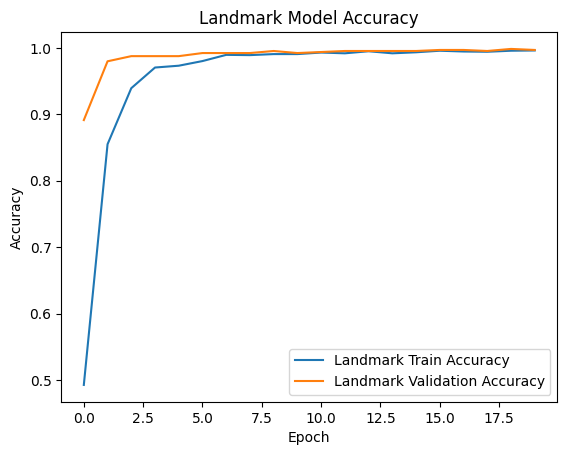

In [23]:
#Graphs - Landmark Model Accuracy
import pickle
import matplotlib.pyplot as plt

with open("landmark_history.pkl", "rb") as f:
    landmark_history_data = pickle.load(f)

plt.plot(landmark_history_data["accuracy"], label="Landmark Train Accuracy")
plt.plot(landmark_history_data["val_accuracy"], label="Landmark Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Landmark Model Accuracy")
plt.legend()
plt.show()

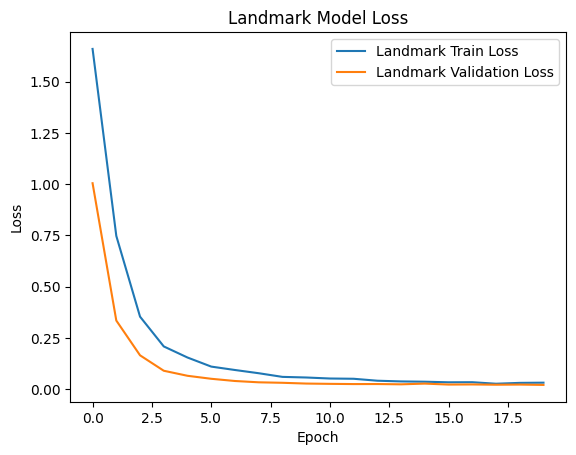

In [11]:
plt.plot(landmark_history_data["loss"], label="Landmark Train Loss")
plt.plot(landmark_history_data["val_loss"], label="Landmark Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Landmark Model Loss")
plt.legend()
plt.show()

21/21 [==============================] - 0s 977us/step


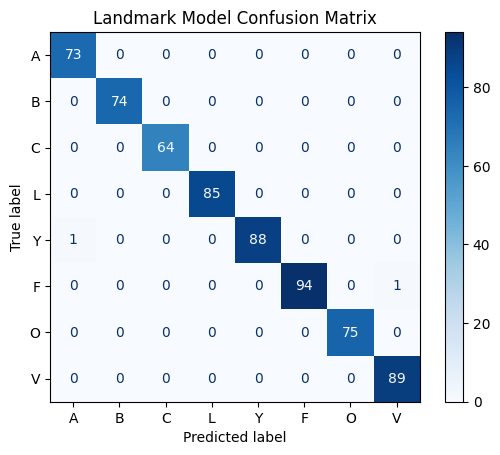

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_pred_probs = landmark_model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=selected_classes
)

disp.plot(cmap="Blues")
plt.title("Landmark Model Confusion Matrix")
plt.show()

In [19]:
import pickle

with open("landmark_history.pkl", "wb") as f:
    pickle.dump(landmark_history.history, f)

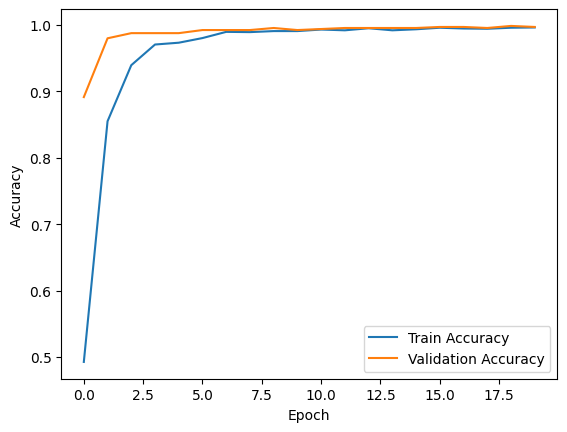

In [20]:
with open("landmark_history.pkl", "rb") as f:
    landmark_history_data = pickle.load(f)

plt.plot(landmark_history.history["accuracy"], label="Train Accuracy")
plt.plot(landmark_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

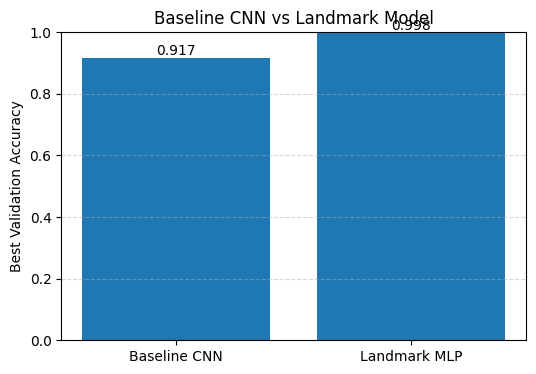

In [22]:
import matplotlib.pyplot as plt

# If CNN history not loaded, fallback to known value
if "cnn_history_data" in globals():
    cnn_best_val = max(cnn_history_data["val_accuracy"])
else:
    cnn_best_val = 0.9175   # your known CNN result

# If landmark history exists
if "landmark_history_data" in globals():
    landmark_best_val = max(landmark_history_data["val_accuracy"])
else:
    landmark_best_val = max(landmark_history.history["val_accuracy"])

models = ["Baseline CNN", "Landmark MLP"]
scores = [cnn_best_val, landmark_best_val]

plt.figure(figsize=(6,4))
bars = plt.bar(models, scores)

# Add value labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center')

plt.ylabel("Best Validation Accuracy")
plt.title("Baseline CNN vs Landmark Model")
plt.ylim(0, 1)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()